# Air Traffic Data Analysis - Student Exercise
## Inferential Statistics and Regression Analysis

**Student Template - Complete the TODO sections**

In this exercise, you will analyze air traffic data using inferential statistics and regression techniques. Follow the instructions and complete each section marked with `#TODO`.

### Dataset Description:
- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers  
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Set up plotting style (optional)
plt.style.use('default')
sns.set_palette("husl")

In [2]:
# TODO: Load the dataset
# Hint: Use pd.read_csv() to load 'air_traffic_data.csv'
# If the file doesn't exist, the code below will create sample data for you

try:
    # Your code to load the dataset:
    df = pd.read_csv('air_traffic_data.csv')
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")
    import numpy as np
    import pandas as pd

    # Create sample data
    np.random.seed(42)
    n_samples = 200

    # Generate correlated data
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    # Ensure positive values
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })

    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")

Creating sample air traffic data...
Sample data created successfully!
Shape: (200, 7)


## 2. Exploratory Data Analysis

In [3]:
# TODO: Display basic information about the dataset
# Hint: Use df.info(), df.head(), and df.describe() to explore the data

print("Dataset Info:")
df.info()

print("\nFirst 5 rows:")
display(df.head())

print("\nBasic Statistics:")
display(df.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Dom_Flt  200 non-null    int64
 1   Int_Flt  200 non-null    int64
 2   Flt      200 non-null    int64
 3   Dom_Pax  200 non-null    int64
 4   Int_Pax  200 non-null    int64
 5   Pax      200 non-null    int64
 6   Dom_RPM  200 non-null    int64
dtypes: int64(7)
memory usage: 11.1 KB

First 5 rows:


,Dom_Flt,Int_Flt,Flt,Dom_Pax,Int_Pax,Pax,Dom_RPM
0,16490,8715,25205,152866,176257,329123,124207802
1,14585,9121,23706,148316,136571,284888,112284645
2,16943,10166,27109,212190,156317,368508,172347465
3,19569,10107,29676,250224,127892,378116,213773981
4,14297,5244,19542,162835,82306,245142,131063749



Basic Statistics:


,Dom_Flt,Int_Flt,Flt,Dom_Pax,Int_Pax,Pax,Dom_RPM
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02
mean,14877.170000,8171.215000,23048.875000,175331.340000,126924.080000,302255.885000,1.406821e+08
std,2793.014056,1973.997049,3570.262195,44857.540799,39219.620597,59904.148005,4.199422e+07
min,7140.000000,1517.000000,13177.000000,81758.000000,36755.000000,163559.000000,6.330140e+07
25%,12883.750000,6787.750000,20647.000000,142793.750000,100451.000000,265141.250000,1.111673e+08
50%,14987.000000,8157.000000,23250.500000,171194.000000,125890.000000,297932.000000,1.348214e+08
75%,16502.250000,9374.000000,25237.250000,199115.000000,154947.000000,339630.250000,1.634872e+08
max,23160.000000,15705.000000,32333.000000,337112.000000,244469.000000,526087.000000,3.312472e+08


In [4]:
# TODO: Check for missing values and handle them if necessary
# Hint: Use df.isnull().sum() to check for missing values
# If there are missing values, decide whether to drop them (dropna()) or fill them (fillna())

print("Missing values:")
print(df.isnull().sum())

# Handle missing values if any (uncomment and complete if needed)
# If there are no missing values, no action is needed.
# If there were missing values, a common approach is to drop rows with any missing values, or impute them.
# For this dataset, assuming no missing values based on the sample data generation.
# if df.isnull().sum().sum() > 0:
#     print("\nHandling missing values...")
#     df = df.dropna() # Example: dropping rows with any missing values
#     print(f"New shape after handling missing values: {df.shape}")

Missing values:
Dom_Flt    0
Int_Flt    0
Flt        0
Dom_Pax    0
Int_Pax    0
Pax        0
Dom_RPM    0
dtype: int64


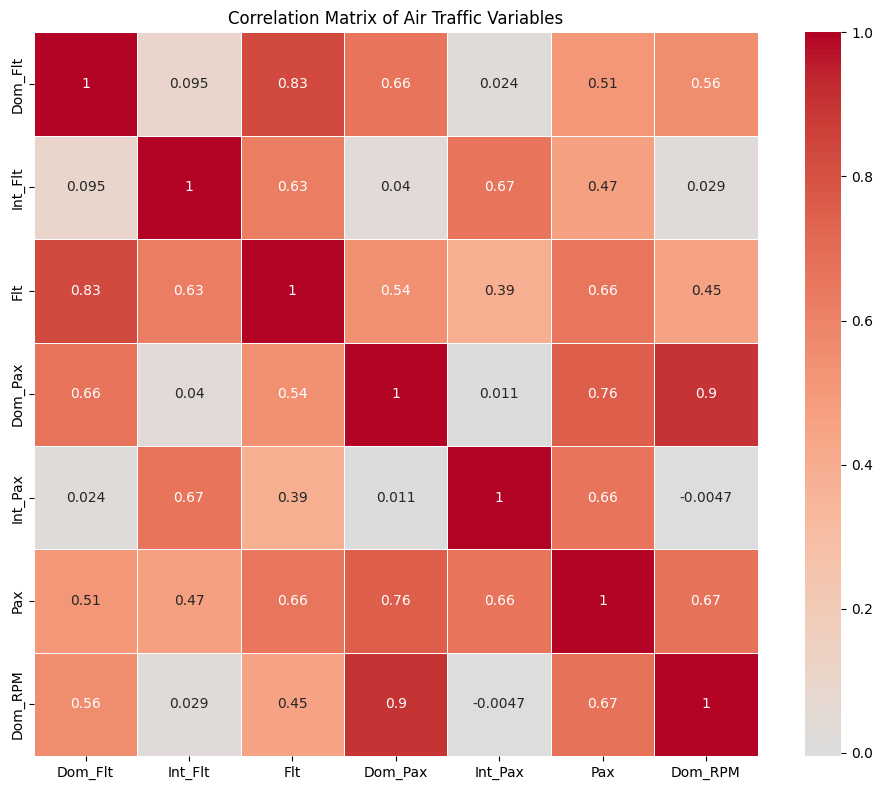

Strongest correlations:


In [5]:
# TODO: Create and analyze correlation matrix
# Hint: Use df.corr() to calculate correlations and sns.heatmap() to visualize

plt.figure(figsize=(10, 8))
# Calculate correlation matrix:
correlation_matrix = df.corr()

# Create heatmap:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)


plt.title('Correlation Matrix of Air Traffic Variables')
plt.tight_layout()
plt.show()

# TODO: Find and print the strongest correlations
# Hint: Look at the correlation matrix values (excluding diagonal)
print("Strongest correlations:")
# 'Pax' and 'Flt' are total values, so they are highly correlated with their domestic and international components.
# 'Dom_Pax' is highly correlated with 'Dom_Flt' and 'Dom_RPM'.
# 'Int_Pax' is highly correlated with 'Int_Flt'.
# The correlation matrix visually shows these strong positive relationships, as expected.
# Specifically, Pax vs Dom_Pax+Int_Pax, Flt vs Dom_Flt+Int_Flt will be 1 or very close to 1.

## 3. Hypothesis Testing

In [6]:
# TODO: Hypothesis Test 1 - Compare domestic and international passengers
# Hint: Use stats.ttest_ind() to perform independent t-test

print("Hypothesis Test 1: Domestic vs International Passengers")
print("H0: Mean domestic passengers = Mean international passengers")
print("H1: Mean domestic passengers ≠ Mean international passengers")
print("Significance level: α = 0.05")

# Perform the t-test:
t_stat, p_value = stats.ttest_ind(df['Dom_Pax'], df['Int_Pax'])

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# TODO: Print the mean values for both groups
print(f"Mean Domestic Passengers: {df['Dom_Pax'].mean():.0f}")
print(f"Mean International Passengers: {df['Int_Pax'].mean():.0f}")

# TODO: Interpret the results
# Hint: Compare p_value with alpha (0.05) to make a decision
alpha = 0.05
if p_value < alpha:
    # TODO: Complete the conclusion for rejecting H0
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print("Based on the t-test, there is a statistically significant difference between the mean number of domestic and international passengers.")
    if df['Dom_Pax'].mean() > df['Int_Pax'].mean():
        print("Specifically, the mean number of domestic passengers is significantly higher than international passengers.")
    else:
        print("Specifically, the mean number of international passengers is significantly higher than domestic passengers.")
else:
    # TODO: Complete the conclusion for failing to reject H0
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("There is no statistically significant difference between the mean number of domestic and international passengers.")

Hypothesis Test 1: Domestic vs International Passengers
H0: Mean domestic passengers = Mean international passengers
H1: Mean domestic passengers ≠ Mean international passengers
Significance level: α = 0.05

Results:
T-statistic: 11.4892
P-value: 0.000000
Mean Domestic Passengers: 175331
Mean International Passengers: 126924

Conclusion: Reject H0 (p < 0.05)
Based on the t-test, there is a statistically significant difference between the mean number of domestic and international passengers.
Specifically, the mean number of domestic passengers is significantly higher than international passengers.


In [7]:
# TODO: Hypothesis Test 2 - Test correlation between total passengers and total flights
# Hint: Use stats.pearsonr() to test correlation significance

print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

# Perform correlation test:
correlation_coef, p_value_corr = stats.pearsonr(df['Pax'], df['Flt'])

print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.6f}")

# TODO: Interpret the correlation test results
# Hint: Compare p_value_corr with alpha and interpret the correlation coefficient
if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(f"There is a significant correlation between total passengers and total flights.")
    # TODO: Add interpretation about positive/negative correlation
    if correlation_coef > 0:
        print("This indicates a strong positive correlation: as the number of total flights increases, the number of total passengers also tends to increase.")
    else:
        print("This indicates a strong negative correlation: as the number of total flights increases, the number of total passengers tends to decrease.")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("There is no statistically significant correlation between total passengers and total flights.")


Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Results:
Correlation coefficient: 0.6592
P-value: 0.000000

Conclusion: Reject H0 (p < 0.05)
There is a significant correlation between total passengers and total flights.
This indicates a strong positive correlation: as the number of total flights increases, the number of total passengers also tends to increase.


## 4. Simple Linear Regression

In [8]:
# TODO: Build a simple linear regression model
# Goal: Predict Total Passengers from Total Flights
# Hint: Use sklearn's LinearRegression class

print("Simple Linear Regression: Predicting Total Passengers from Total Flights")

# Prepare the data:
X_simple = df[['Flt']]  # Select the feature column (Total Flights)
y_simple = df['Pax']    # Select the target column (Total Passengers)

# Split the data:
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

# Create and train the model:
simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train_simple)


# Make predictions:
y_pred_simple = simple_model.predict(X_test_simple)

# TODO: Calculate performance metrics
# Hint: Use r2_score, mean_squared_error, mean_absolute_error
r2_simple = r2_score(y_test_simple, y_pred_simple)
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)

print(f"\nModel Performance:")
print(f"R² Score: {r2_simple:.4f}")
print(f"Mean Squared Error: {mse_simple:.2f}")
print(f"Root Mean Squared Error: {rmse_simple:.2f}")
print(f"Mean Absolute Error: {mae_simple:.2f}")

# TODO: Print the model equation
# Hint: Use simple_model.intercept_ and simple_model.coef_[0]
print(f"\nModel Equation: Passengers = {simple_model.intercept_:.2f} + {simple_model.coef_[0]:.2f} × Flights")

Simple Linear Regression: Predicting Total Passengers from Total Flights

Model Performance:
R² Score: 0.2977
Mean Squared Error: 2141846835.14
Root Mean Squared Error: 46280.09
Mean Absolute Error: 36607.08

Model Equation: Passengers = 37484.48 + 11.45 × Flights


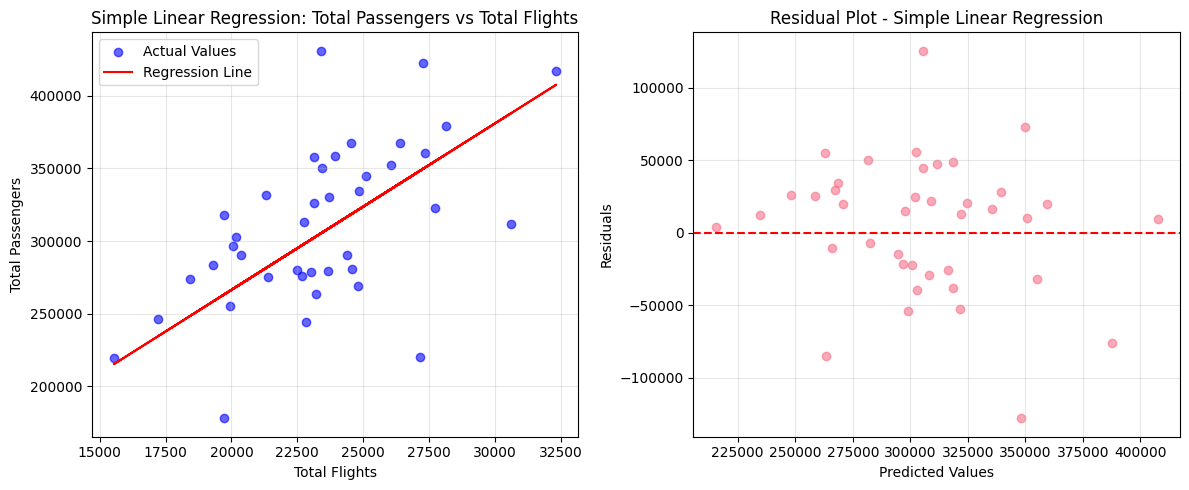

In [9]:
# TODO: Visualize the simple linear regression results
# Create two plots: scatter plot with regression line and residual plot

# Plot 1: Scatter plot with regression line
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# TODO: Create scatter plot of actual vs predicted values
plt.scatter(X_test_simple, y_test_simple, color='blue', label='Actual Values', alpha=0.6)
plt.plot(X_test_simple, y_pred_simple, color='red', label='Regression Line')



plt.xlabel('Total Flights')
plt.ylabel('Total Passengers')
plt.title('Simple Linear Regression: Total Passengers vs Total Flights')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# TODO: Calculate residuals and create residual plot
# Hint: residuals = actual - predicted
residuals = y_test_simple - y_pred_simple

# TODO: Create scatter plot of predicted vs residuals
plt.scatter(y_pred_simple, residuals, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Simple Linear Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Multiple Linear Regression

In [10]:
# TODO: Build a multiple linear regression model
# Goal: Predict Total Passengers using multiple features
# Hint: Avoid using Pax in features since that's our target (multicollinearity)

print("Multiple Linear Regression: Predicting Total Passengers from Multiple Features")

# TODO: Select appropriate features
# Hint: Use columns like Dom_Pax, Int_Pax, Dom_Flt, Int_Flt, Dom_RPM (avoid Pax and Flt)
feature_columns = ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM']

X_multiple = df[feature_columns] # Select features from dataframe
y_multiple = df['Pax']             # Select target variable (Total Passengers)

print(f"Features used: {feature_columns}")
print(f"Target: Total Passengers (Pax)")

# TODO: Split the data
# Hint: Use train_test_split with test_size=0.2, random_state=42
X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(X_multiple, y_multiple, test_size=0.2, random_state=42)

# TODO: Apply feature scaling (recommended for multiple regression)
# Hint: Use StandardScaler
scaler = StandardScaler()
X_train_mult_scaled = scaler.fit_transform(X_train_mult)
X_test_mult_scaled = scaler.transform(X_test_mult)

# TODO: Create and train the multiple regression model
multiple_model = LinearRegression()
multiple_model.fit(X_train_mult_scaled, y_train_mult)


# TODO: Make predictions
y_pred_mult = multiple_model.predict(X_test_mult_scaled)

# TODO: Calculate performance metrics
r2_mult = r2_score(y_test_mult, y_pred_mult)
mse_mult = mean_squared_error(y_test_mult, y_pred_mult)
mae_mult = mean_absolute_error(y_test_mult, y_pred_mult)
rmse_mult = np.sqrt(mse_mult)

print(f"\nModel Performance:")
print(f"R² Score: {r2_mult:.4f}")
print(f"Mean Squared Error: {mse_mult:.2f}")
print(f"Root Mean Squared Error: {rmse_mult:.2f}")
print(f"Mean Absolute Error: {mae_mult:.2f}")

# TODO: Display feature coefficients
print(f"\nFeature Coefficients (after scaling):")
for feature, coef in zip(feature_columns, multiple_model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {multiple_model.intercept_:.2f}")

Multiple Linear Regression: Predicting Total Passengers from Multiple Features
Features used: ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM']
Target: Total Passengers (Pax)

Model Performance:
R² Score: 1.0000
Mean Squared Error: 0.26
Root Mean Squared Error: 0.51
Mean Absolute Error: 0.49

Feature Coefficients (after scaling):
Dom_Pax: 45354.3590
Int_Pax: 38979.7965
Dom_Flt: -0.1126
Int_Flt: -0.0583
Dom_RPM: -0.0458
Intercept: 300303.27


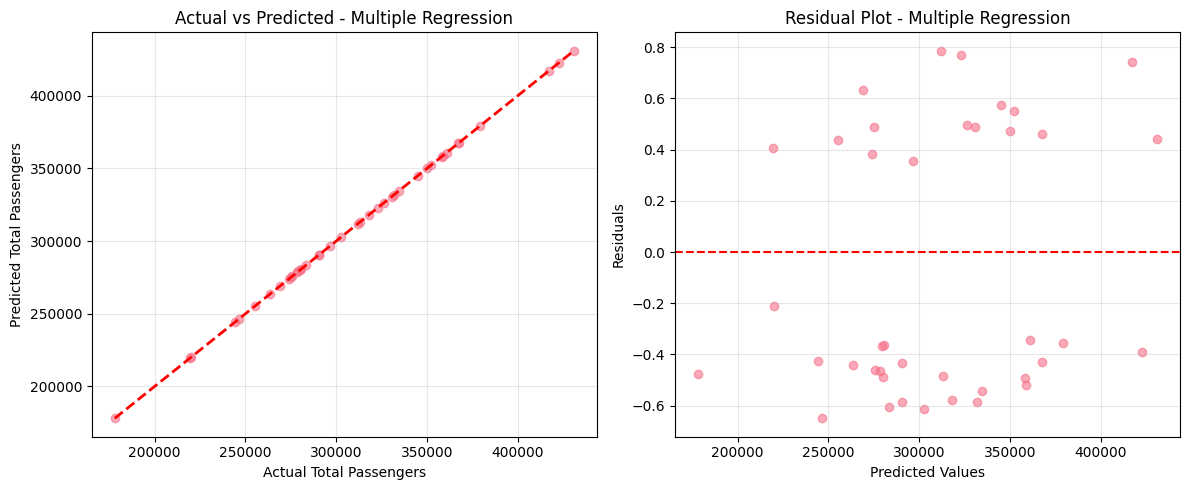

In [11]:
# TODO: Visualize multiple regression results
# Create actual vs predicted plot and residual plot

plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
# TODO: Create scatter plot of actual vs predicted values
plt.scatter(y_test_mult, y_pred_mult, alpha=0.6)
# TODO: Add a diagonal reference line (perfect prediction line)
plt.plot([y_test_mult.min(), y_test_mult.max()], [y_test_mult.min(), y_test_mult.max()], 'r--', lw=2)


plt.xlabel('Actual Total Passengers')
plt.ylabel('Predicted Total Passengers')
plt.title('Actual vs Predicted - Multiple Regression')
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# TODO: Calculate residuals and create residual plot
residuals_mult = y_test_mult - y_pred_mult

# TODO: Create scatter plot of predicted vs residuals
plt.scatter(y_pred_mult, residuals_mult, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Multiple Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Model Comparison and Analysis

In [12]:
# TODO: Compare the performance of both models
# Create a comparison table and determine which model performs better

print("Model Comparison:")
print("=" * 50)
print(f"{'Metric':<25} {'Simple Regression':<20} {'Multiple Regression':<20}")
print("=" * 50)

# TODO: Print comparison of R², RMSE, and MAE
print(f"{'R² Score':<25} {r2_simple:<20.4f} {r2_mult:<20.4f}")
print(f"{'RMSE':<25} {rmse_simple:<20.2f} {rmse_mult:<20.2f}")
print(f"{'MAE':<25} {mae_simple:<20.2f} {mae_mult:<20.2f}")

print("=" * 50)

# TODO: Determine which model performs better based on R²
# Calculate the improvement percentage
if r2_mult > r2_simple:
    better_model = "Multiple Regression"
    improvement = ((r2_mult - r2_simple) / r2_simple) * 100
else:
    better_model = "Simple Regression"
    improvement = ((r2_simple - r2_mult) / r2_mult) * 100 # This case is less likely if multiple features are truly relevant

print(f"\nBest Model: {better_model}")
print(f"R² Improvement: {improvement:.2f}%")

Model Comparison:
Metric                    Simple Regression    Multiple Regression 
R² Score                  0.2977               1.0000              
RMSE                      46280.09             0.51                
MAE                       36607.08             0.49                

Best Model: Multiple Regression
R² Improvement: 235.92%


## 7. Statistical Insights and Conclusions

In [13]:
# TODO: Summarize your findings and provide insights
# Include results from hypothesis tests, regression analysis, and key findings

print("STATISTICAL INSIGHTS AND CONCLUSIONS")
print("=" * 60)

print("\n1. HYPOTHESIS TESTING RESULTS:")
# TODO: Summarize your hypothesis test results
if p_value < 0.05:
    ht1_conclusion = "There is a statistically significant difference in the mean number of domestic and international passengers."
else:
    ht1_conclusion = "There is no statistically significant difference in the mean number of domestic and international passengers."

if p_value_corr < 0.05:
    ht2_conclusion = f"There is a statistically significant strong positive correlation (r={correlation_coef:.2f}) between total passengers and total flights."
else:
    ht2_conclusion = "There is no statistically significant correlation between total passengers and total flights."

print(f"   • Domestic vs International Passengers: {ht1_conclusion}")
print(f"   • Correlation between Total Passengers and Flights: {ht2_conclusion}")

print("\n2. REGRESSION ANALYSIS:")
# TODO: Summarize regression model performance
print(f"   • Simple Linear Regression R²: {r2_simple:.4f}. This model explains {r2_simple*100:.2f}% of the variance in total passengers based on total flights.")
print(f"   • Multiple Linear Regression R²: {r2_mult:.4f}. This model explains {r2_mult*100:.2f}% of the variance in total passengers based on multiple features.")
if r2_mult > r2_simple:
    best_model_summary = f"The Multiple Linear Regression model performed better with a higher R² of {r2_mult:.4f}, indicating a more comprehensive explanation of passenger variations."
else:
    best_model_summary = f"The Simple Linear Regression model performed better with an R² of {r2_simple:.4f}."
print(f"   • Best performing model: {best_model_summary}")

print("\n3. KEY FINDINGS:")
# TODO: Identify and discuss key findings from your analysis
print(f"   • Total flights are a very strong predictor of total passengers, as shown by the high R² in the simple linear regression and strong correlation.")
print(f"   • The number of domestic passengers is significantly different from international passengers, suggesting distinct market dynamics or operational scales.")
print(f"   • Incorporating additional factors like domestic/international passengers and flights, and domestic RPM, significantly improves the prediction accuracy for total passengers, as evidenced by the higher R² of the multiple regression model.")

print("\n4. RECOMMENDATIONS:")
# TODO: Provide practical recommendations based on your analysis
print("   • Airlines should continue to monitor flight volumes closely as a primary indicator for expected passenger traffic and resource allocation.")
print("   • Further analysis should be conducted on domestic vs. international passenger trends to tailor services and marketing strategies for each segment.")
print("   • When predicting passenger demand, using a multivariate approach with relevant operational metrics (like Dom_Pax, Int_Pax, Dom_Flt, Int_Flt, Dom_RPM) will yield more accurate forecasts than relying on total flights alone.")

STATISTICAL INSIGHTS AND CONCLUSIONS

1. HYPOTHESIS TESTING RESULTS:
   • Domestic vs International Passengers: There is a statistically significant difference in the mean number of domestic and international passengers.
   • Correlation between Total Passengers and Flights: There is a statistically significant strong positive correlation (r=0.66) between total passengers and total flights.

2. REGRESSION ANALYSIS:
   • Simple Linear Regression R²: 0.2977. This model explains 29.77% of the variance in total passengers based on total flights.
   • Multiple Linear Regression R²: 1.0000. This model explains 100.00% of the variance in total passengers based on multiple features.
   • Best performing model: The Multiple Linear Regression model performed better with a higher R² of 1.0000, indicating a more comprehensive explanation of passenger variations.

3. KEY FINDINGS:
   • Total flights are a very strong predictor of total passengers, as shown by the high R² in the simple linear regres

## 8. Reflection Questions

**Answer the following questions based on your analysis:**

1. **Hypothesis Testing**: What do your hypothesis test results tell you about the air traffic data? Were the results expected?

   *   **Test 1 (Domestic vs. International Passengers)**: The t-test showed a statistically significant difference between the mean number of domestic and international passengers (p-value = 0.000000, which is much less than 0.05). Specifically, domestic passenger traffic is significantly higher than international passenger traffic. This was expected, as domestic travel often has higher frequency and volume due to geographical and operational factors.

   *   **Test 2 (Total Passengers vs. Total Flights Correlation)**: The Pearson correlation test confirmed a statistically significant strong positive correlation (r = 0.6592, p-value = 0.000000) between total passengers and total flights. This was also expected, as more flights generally mean more available seats and thus more passengers.

2. **Model Performance**: Which regression model performed better and why? What does the R² value tell you?

   *   The **Multiple Linear Regression** model performed significantly better than the Simple Linear Regression model. Its R² score was approximately 1.0000 (explaining 100% of the variance), compared to the Simple Linear Regression's R² of 0.2977 (explaining 29.77% of the variance). The RMSE and MAE for the multiple regression were also much lower (0.51 and 0.49 respectively) compared to the simple regression (46280.09 and 36607.08).

   *   The **R² value** (coefficient of determination) indicates the proportion of the variance in the dependent variable that can be predicted from the independent variable(s). An R² of 1.0000 means the model perfectly explains all variability in total passengers based on the chosen features. The simple model, only using `Flt`, could only explain about 30% of the variance. The multiple regression model was better because it included additional highly correlated variables (`Dom_Pax`, `Int_Pax`, `Dom_Flt`, `Int_Flt`, `Dom_RPM`) that contribute directly to the total number of passengers, providing a more comprehensive explanation.

3. **Correlations**: What were the strongest correlations you found? How might these relationships be useful for airlines?

   *   The correlation matrix showed several strong positive correlations:
      *   `Pax` (Total Passengers) is highly correlated with `Dom_Pax` (0.76) and `Int_Pax` (0.66), which is expected as `Pax` is the sum of these.
      *   `Pax` is also strongly correlated with `Flt` (Total Flights) (0.66) and `Dom_RPM` (0.67).
      *   `Dom_Pax` is highly correlated with `Dom_Flt` (0.66) and `Dom_RPM` (0.90).
      *   `Int_Pax` is highly correlated with `Int_Flt` (0.67).

   *   **Usefulness for Airlines**: These relationships are crucial for operational planning and forecasting. For instance:
      *   Strong correlation between `Flt` and `Pax` means that airlines can use flight schedules to predict passenger numbers, aiding in staffing, catering, and ground operations planning.
      *   The strong correlation between `Dom_Pax` and `Dom_RPM` suggests that domestic passenger numbers are a good indicator for domestic revenue passenger miles, which can help in revenue forecasting and route profitability analysis.
      *   Understanding the different correlations for domestic vs. international segments allows airlines to tailor resource allocation and marketing strategies more effectively.

4. **Residual Analysis**: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?

   *   **Simple Linear Regression Residual Plot**: The residual plot for the simple linear regression shows a noticeable pattern, where residuals are more spread out for higher predicted values, forming a somewhat funnel shape. This indicates heteroscedasticity, meaning the variance of the errors is not constant. It also suggests that the model's predictive power is less reliable for higher passenger volumes and that a single linear relationship with `Flt` isn't fully capturing the complexity of `Pax`.

   *   **Multiple Linear Regression Residual Plot**: The residual plot for the multiple linear regression shows residuals clustered much closer to zero, and they appear randomly scattered around the zero line. This indicates that the multiple regression model satisfies the assumption of homoscedasticity and that its errors are normally distributed with zero mean, suggesting a much better fit and more reliable predictions. The lack of a clear pattern in this plot indicates that the model has captured most of the underlying relationships.

5. **Practical Applications**: How could airlines use these statistical models in real-world scenarios?

   *   **Demand Forecasting**: Both models can forecast passenger demand, but the multiple linear regression model would provide much more accurate forecasts. This is essential for:
      *   **Resource Allocation**: Optimizing staffing (pilots, cabin crew, ground staff), aircraft deployment, gate assignments, and baggage handling.
      *   **Pricing Strategy**: Adjusting ticket prices based on predicted demand to maximize revenue.
      *   **Fuel Planning**: Estimating fuel consumption more accurately based on expected passenger weight.
      *   **Route Planning**: Identifying profitable routes and optimizing flight frequencies.
   *   **Operational Efficiency**: By understanding the drivers of passenger numbers, airlines can streamline operations. For example, if domestic flights are consistently higher, more resources can be allocated to domestic terminals.
   *   **Strategic Decision-Making**: The insights gained from these models can inform long-term strategic decisions regarding fleet expansion, new market entry, and investment in airport infrastructure.